# Final project

These two problems are classification problems using only Feedforward Neural Networks.

## Problem 1. Classification of cardiovascular diseases

- Classify patients with and without cardiovascular diseases.
- Would be possible to obtain the impact of different features on the disease prediction?

We will use the dataset [SAHeart](https://www.kaggle.com/datasets/waalbannyantudre/south-african-heart-disease-dataset) from Kaggle.

In [57]:
import pandas as pd

df = pd.read_csv('datasets/SAHeart.csv')
df.head()

,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


| Variable    | Description                                                   |
|------------|----------------------------------------------------------------|
| sbp        | Systolic blood pressure                                        |
| tobacco    | Cumulative tobacco consumption (kg)                             |
| ldl        | Low-density lipoprotein cholesterol level                       |
| adiposity  | Severe overweight (numeric)                                     |
| famhist    | Family history of heart disease                                 |
| typea      | Type-A behavior                                                 |
| obesity    | Excessive fat accumulation (numeric)                            |
| alcohol    | Current alcohol consumption                                     |
| age        | Age at onset                                                    |
| chd        | Coronary heart disease (response: 1 = yes, 0 = no)              |


Type A behavior is characterized by:
- High competitiveness
- Time urgency (always in a hurry)
- Aggressiveness or hostility
- Strong achievement orientation
- Difficulty relaxing

> In cardiovascular studies, Type A behavior has been linked to an increased risk of coronary heart disease (CHD) due to chronic stress and elevated physiological responses (e.g., higher blood pressure, cortisol).

### Preparing the dataset

We drop the 'row.names' column as it is not relevant for our analysis.

In [58]:
df.drop(columns=['row.names'], inplace=True)
print("Dataset shape:", df.shape)

Dataset shape: (462, 10)


The dataset is a bit too small to train a neural network, but we will use it for practice purposes.

Encode categorical variable 'famhist' to numerical values


In [60]:
from sklearn.preprocessing import LabelEncoder

# df['famhist'] = df['famhist'].map({'Present': 1, 'Absent': 0}) # If there's a value not mapped, it will be set to NaN
# df['famhist'] = df['famhist'].apply(lambda x: 1 if x == 'Present' else 0) # Slower than map, unexpected values will be set to 0
le = LabelEncoder()
df['famhist'] = le.fit_transform(df['famhist']) # Best option, unexpected values will be assigned a new integer. Caveats: Order is alphabetical, not meaningful
# ['Absent', 'Present'] -> [0, 1]
df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,1,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,0,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,1,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,1,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,1,60,25.99,57.34,49,1


We check for null values and data types.

In [61]:
print("There are null values in the dataset." if df.isnull().values.any() else "No null values found in the dataset.")
df.dtypes

No null values found in the dataset.


sbp            int64
tobacco      float64
ldl          float64
adiposity    float64
famhist        int64
typea          int64
obesity      float64
alcohol      float64
age            int64
chd            int64
dtype: object

In [62]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import SGD, Adam

Let's see now the distribution of the target variable 'chd', so we can see if the dataset is balanced or not and outlier presence.

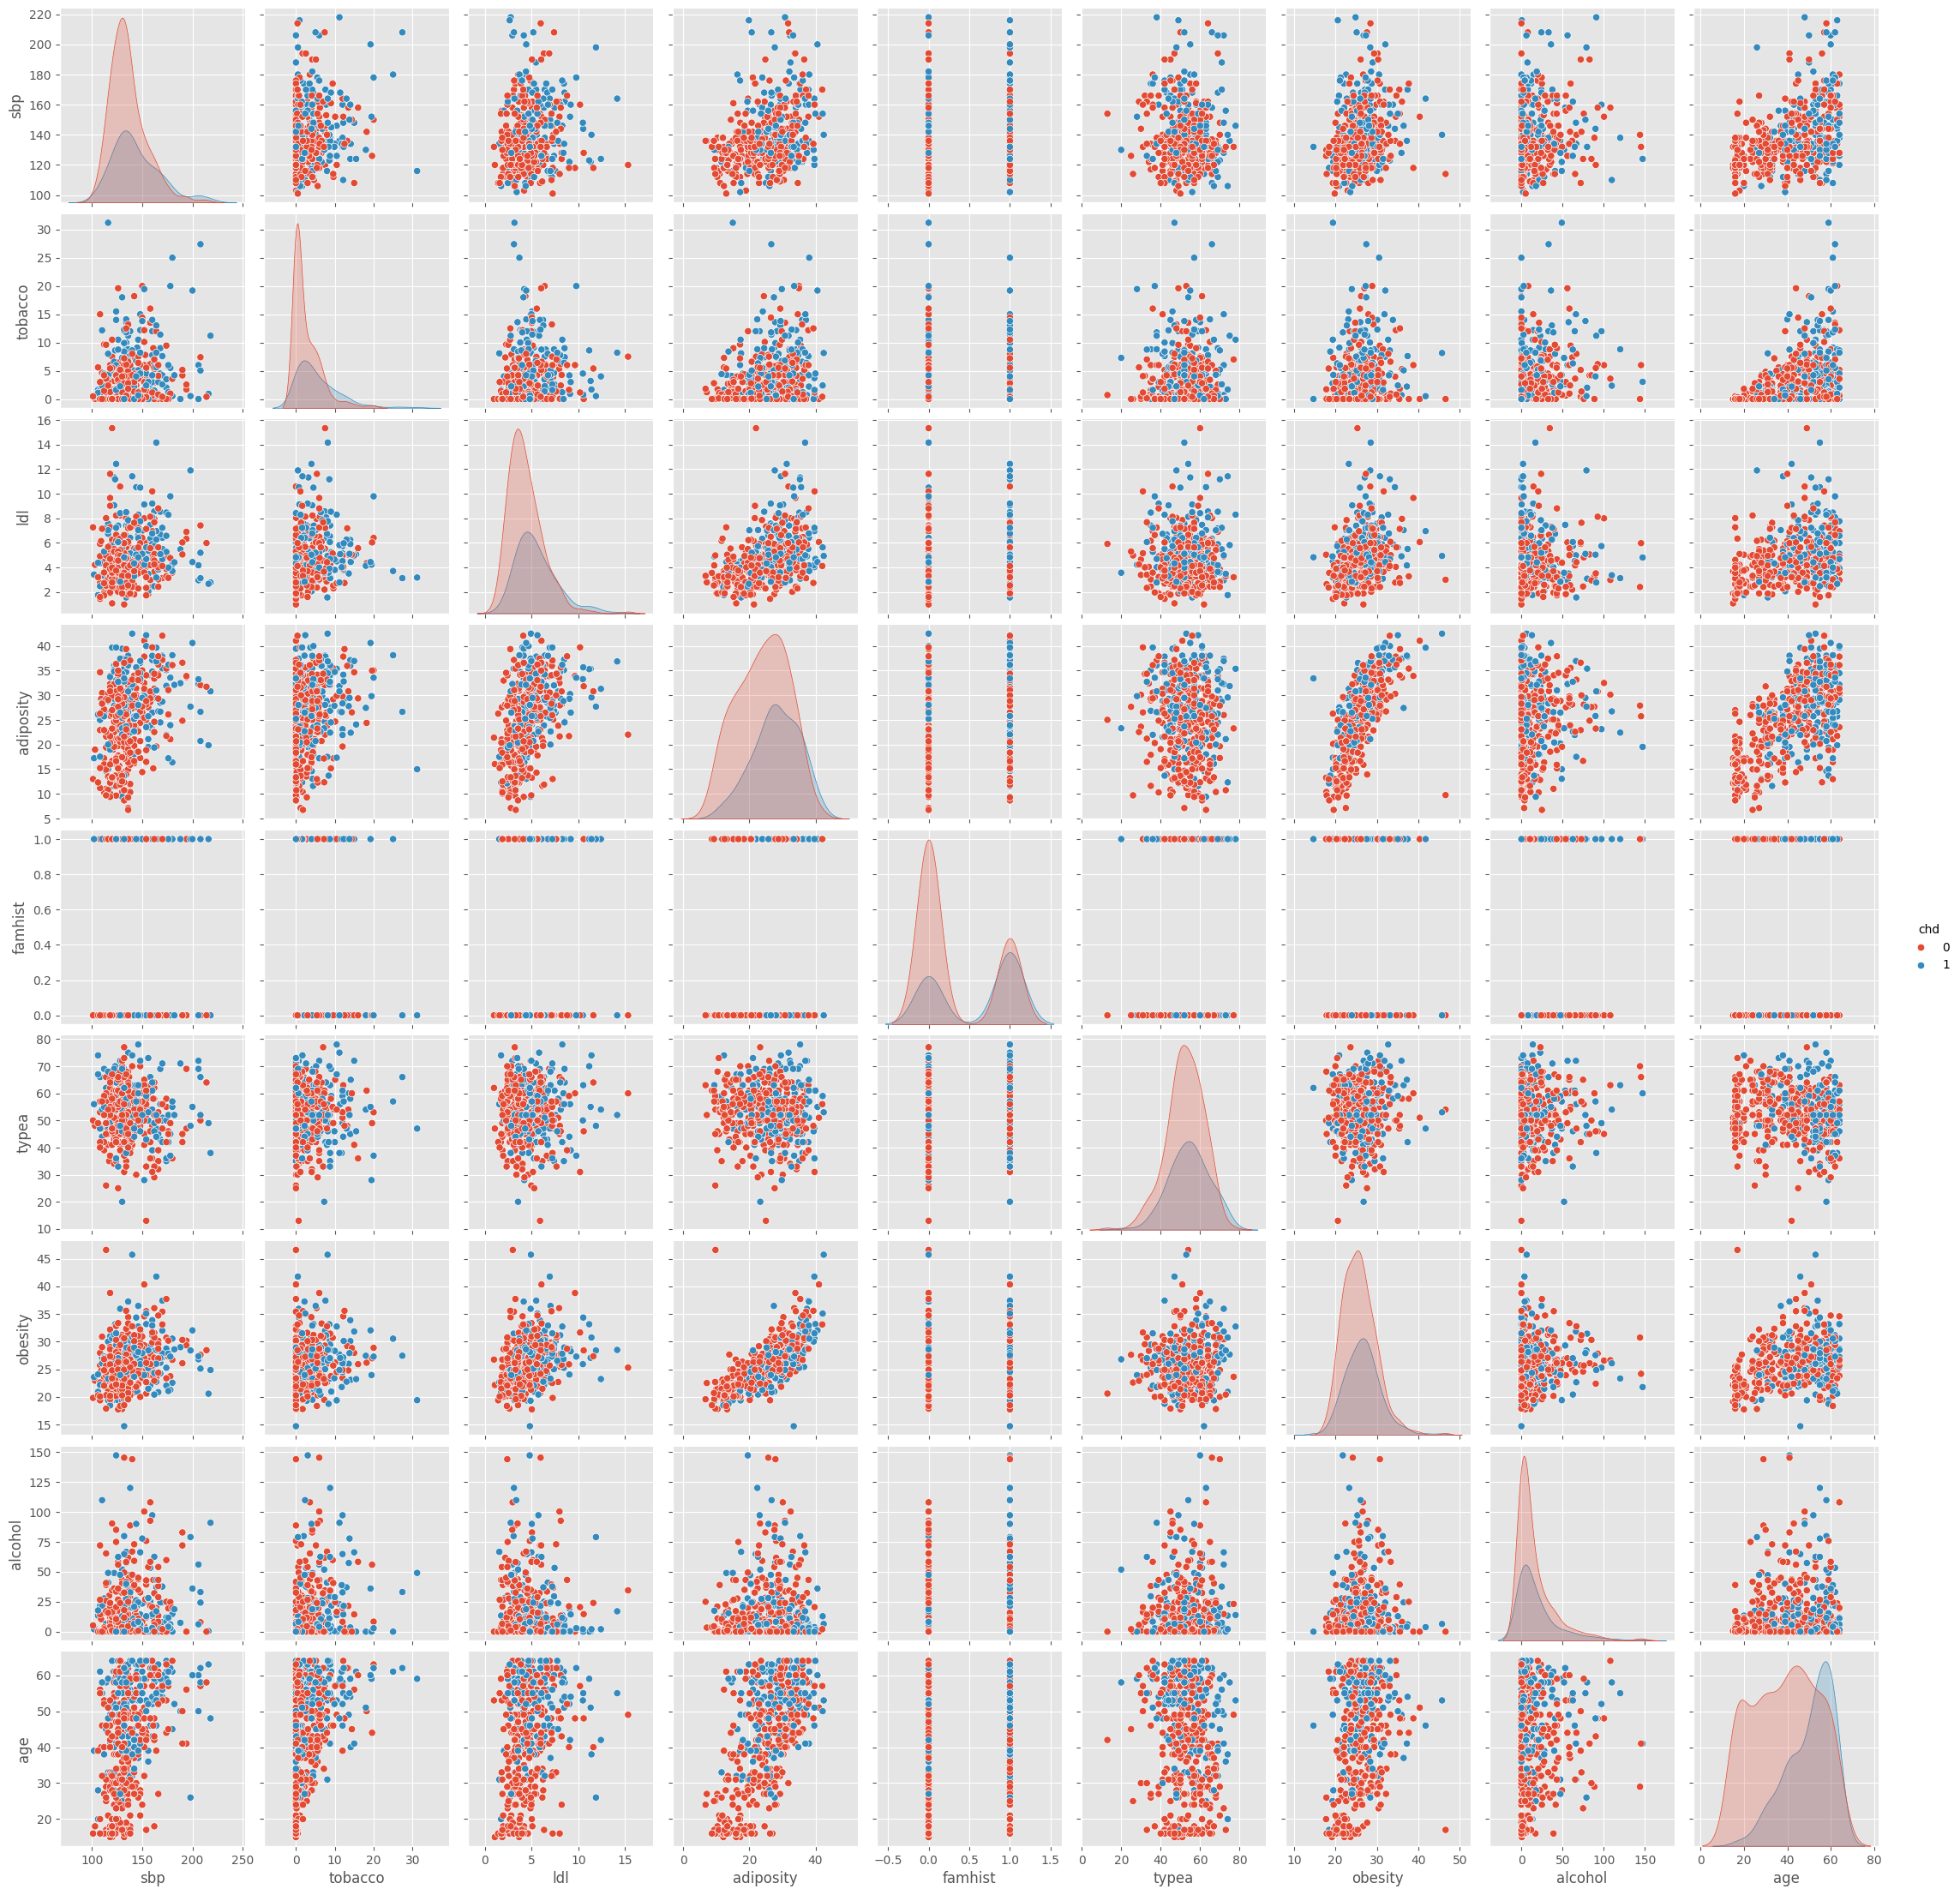

In [63]:
sns.pairplot(df, hue='chd')

The distribution for famhist is bimodal, indicating two distinct groups: those with a family history of heart disease and those without, as expected, and they are balanced.

We see that is not easy to separate both classes with just two features. We will need to use more features to improve the classification.

Most of the features have different scales, so we will standardize them.

We create two methods for data visualization: plot_grid and print_metrics.

In [64]:
def plot_grid(X, y, grid_size):
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(8, 10))

    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            index = i * grid_size[1] + j
            if index < X.shape[1]:
                axes[i, j].scatter(X[:, index], y, alpha=0.5)
                axes[i, j].set_title(f'Feature {index}')
            else:
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

def print_metrics(predictions, y_test, H, epochs):
    print(classification_report(y_test, predictions))

    plt.style.use("ggplot")
    plt.figure()
    plt.plot(np.arange(0, epochs), H.history["loss"], label="train_loss")
    plt.plot(np.arange(0, epochs), H.history["val_loss"], label="val_loss")
    plt.plot(np.arange(0, epochs), H.history["accuracy"], label="train_accuracy")
    plt.plot(np.arange(0, epochs), H.history["val_accuracy"], label="val_accuracy")
    plt.title("Training Loss and Accuracy")
    plt.xlabel("Epoch #")
    plt.ylabel("Loss/Accuracy")
    plt.legend()
    plt.show()

Now we remove the target variable 'chd' from the dataset. Then we will normalize the data and finally we will create a training and a test dataset

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_original = df.drop(columns=['chd'])
y = df['chd']

X = MinMaxScaler().fit_transform(X_original)
X = pd.DataFrame(X, columns=X_original.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age
0,0.504274,0.384615,0.331010,0.457902,1.0,0.553846,0.332497,0.660371,0.755102
1,0.367521,0.000321,0.239024,0.611748,0.0,0.646154,0.444479,0.013996,0.979592
2,0.145299,0.002564,0.174216,0.714406,1.0,0.600000,0.452949,0.025885,0.632653
3,0.589744,0.240385,0.378397,0.875245,1.0,0.584615,0.542346,0.164821,0.877551
4,0.282051,0.435897,0.175610,0.588531,1.0,0.723077,0.354141,0.389565,0.693878


### Designing and training a neural network

We need to design a neural network for binary classification (sigmoid activation function in the output layer).
- The input layer will have 9 neurons (one for each feature).
- We will use one or two hidden layers with a variable number of neurons (we will experiment with this).
- The output layer will have one neuron (binary classification).

In [66]:
# model = Sequential()
# model.add(Input(shape=(X_train.shape[1],)))
# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.15))
# model.add(Dense(16, activation='relu'))
# model.add(Dropout(0.15))
# model.add(Dense(1, activation='sigmoid'))

# Alternative way to define the model
model = Sequential([
    Input(shape=(9,)),
    Dense(32, activation='relu'),
    Dropout(0.15),
    Dense(16, activation='relu'),
    Dropout(0.15),
    Dense(1, activation='sigmoid')
])

# Adam or SGD optimizers can be used. Adam is more advanced, but SGD is simpler and sometimes better for generalization.
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

Now we can train the neural network with different configurations and see the results.
> We send as parameter the validation data to monitor the test accuracy during training of each epoch.

In [68]:
H = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4770 - loss: 0.6989 - val_accuracy: 0.6989 - val_loss: 0.6746
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6721 - loss: 0.6722 - val_accuracy: 0.6344 - val_loss: 0.6617
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6775 - loss: 0.6545 - val_accuracy: 0.6344 - val_loss: 0.6539
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6558 - loss: 0.6510 - val_accuracy: 0.6344 - val_loss: 0.6460
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6558 - loss: 0.6439 - val_accuracy: 0.6344 - val_loss: 0.6386
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6640 - loss: 0.6353 - val_accuracy: 0.6344 - val_loss: 0.6335
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6694 - loss: 0.6332 - val_accuracy: 0.6344 - val_loss: 0.6250
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6911 - loss: 0.6201 - val_accuracy: 0.6989 - val_loss:

Now we do a prediction with the test dataset and we print the metrics.

In [69]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.44f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7527 - loss: 0.5228
Test Loss: 0.5228, Test Accuracy: 0.75268816947937011718750000000000000000000000


We round the predictions to get binary outputs (0 or 1).

In [70]:
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


              precision    recall  f1-score   support

           0       0.75      0.92      0.82        59
           1       0.76      0.47      0.58        34

    accuracy                           0.75        93
   macro avg       0.76      0.69      0.70        93
weighted avg       0.75      0.75      0.74        93



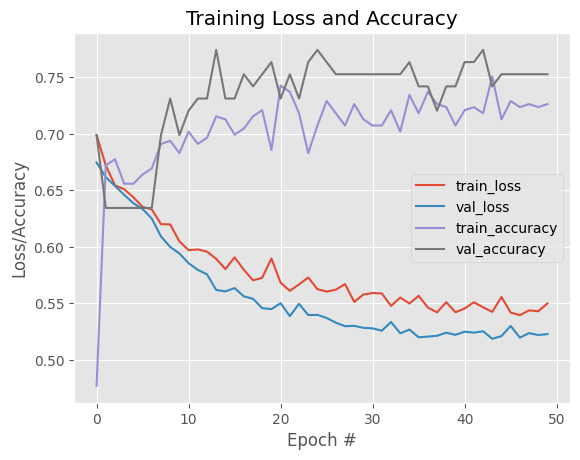

In [71]:
print_metrics(predictions, y_test, H, epochs=50)

Here with neural network we don't check first the confusion matrix, but first we see the loss and accuracy of the model given epochs.
> Once we have verified that the model is working properly, we can see the confusion matrix and other metrics.

Validation accuracy is higher than training accuracy, indicating that the model is not overfitting and is generalizing well to unseen data. So we can try to increase the complexity of the model to improve performance.

In [74]:
def train_and_evaluate_model(n_value, dropout_value, optimizer, X_train, X_test, y_train, y_test, batch_size=16, epochs=50):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    
    model.add(Dense(2 ** n_value, activation='relu'))
    model.add(Dropout(dropout_value))
    model.add(Dense(2 ** (n_value - 1), activation='relu'))
    model.add(Dropout(dropout_value))
    
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=False)
    
    loss, accuracy = model.evaluate(X_test, y_test)

    return loss, accuracy

We create a random grid search to find the best hyperparameters for the neural network, using different number of hidden layers, neurons, learning rates, and batch sizes.

In [82]:
n_values = [3, 4, 5, 6]
dropout_values = [0.1, 0.2, 0.5]
optimizers = ['sgd', 'adam']
epochs = [50, 100, 150]
results = {
    'n_value': [],
    'dropout_value': [],
    'optimizer': [],
    'epochs': [],
    'loss': [],
    'accuracy': []
}

total_combinations = len(n_values) * len(dropout_values) * len(optimizers) * len(epochs)


with tqdm(total=total_combinations, desc="Training Models") as pbar:
    for n in n_values:
        for dropout in dropout_values:
            for optimizer in optimizers:
                for epoch in epochs:
                    loss, accuracy = train_and_evaluate_model(n, dropout, optimizer, X_train, X_test, y_train, y_test, epochs=epoch)
                    
                    results['n_value'].append(n)
                    results['dropout_value'].append(dropout)
                    results['optimizer'].append(optimizer)
                    results['epochs'].append(epoch)
                    results['loss'].append(loss)
                    results['accuracy'].append(accuracy)
                    
                    pbar.update(1)

Training Models:   0%|          | 0/72 [00:00<?, ?it/s]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6344 - loss: 0.6157


Training Models:   1%|▏         | 1/72 [00:03<04:29,  3.80s/it]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6344 - loss: 0.6555 


Training Models:   3%|▎         | 2/72 [00:10<06:31,  5.59s/it]

...

Training Models:  97%|█████████▋| 70/72 [08:31<00:13,  6.96s/it]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7634 - loss: 0.5123 


Training Models:  99%|█████████▊| 71/72 [08:38<00:07,  7.14s/it]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7527 - loss: 0.5182 


Training Models: 100%|██████████| 72/72 [08:50<00:00,  7.37s/it]


Now we sort out the best results and print the top 5 configurations.

In [83]:
results = pd.DataFrame(results)
results = results.sort_values(by='accuracy', ascending=False)
print(results.head(5))

    n_value  dropout_value optimizer  epochs      loss  accuracy
41        5            0.1      adam     150  0.534170  0.784946
56        6            0.1       sgd     150  0.517302  0.784946
58        6            0.1      adam     100  0.546044  0.784946
23        4            0.1      adam     150  0.508932  0.784946
64        6            0.2      adam     100  0.540790  0.774194


Now that we know the best hyperparameters, we can train a final model with them and see the results.

In [84]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(2**5, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(2**4, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_153"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_459 (Dense)               │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_302 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_460 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_303 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_461 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
H = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=150, batch_size=16)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6233 - loss: 0.6715 - val_accuracy: 0.6237 - val_loss: 0.6609
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6504 - loss: 0.6572 - val_accuracy: 0.6344 - val_loss: 0.6473
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6450 - loss: 0.6399 - val_accuracy: 0.6344 - val_loss: 0.6297
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6558 - loss: 0.6298 - val_accuracy: 0.6344 - val_loss: 0.6156
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6531 - loss: 0.6261 - val_accuracy: 0.6559 - val_loss: 0.6034
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6829 - loss: 0.6120 - val_accuracy: 0.7312 - val_loss: 0.5932
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7019 - loss: 0.5978 - val_accuracy: 0.6989 - val_loss: 0.5845
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6911 - loss: 0.5872 - val_accuracy: 0.7312 - v

In [86]:
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


              precision    recall  f1-score   support

           0       0.75      0.92      0.82        59
           1       0.76      0.47      0.58        34

    accuracy                           0.75        93
   macro avg       0.76      0.69      0.70        93
weighted avg       0.75      0.75      0.74        93



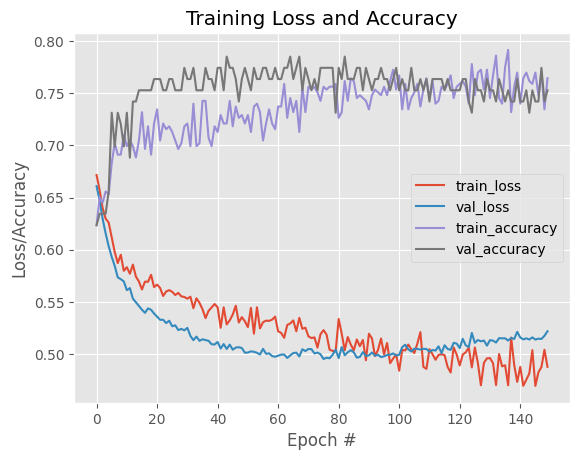

In [87]:
print_metrics(predictions, y_test, H, epochs=150)

Looking into the metrics with the best hyperparameters for the model, we can see that after 60 epochs there is noise in the validation accuracy and loss, indicating that the model is starting to overfit. We could try to add another layer or try a different number of neurons to improve the model.

To know how the different features impact the disease prediction, we can use  [SHAP](https://shap.readthedocs.io/en/latest/) (SHapley Additive exPlanations) values to interpret the model's predictions.

> If we weren't using SHAP the other option would be removing features one by one and see how the model performance changes, but once we have a model relatively optimized and stable (still SHAP is better for this task).

## Problem 2. Image classification
- Build a neural network model to classify images from the CIFAR-10 dataset.
- Get metrics of the model and analyze its performance.
- Are all classes equally well predicted? Which classes are more difficult to classify and why?

We will use the dataset [MNIST dataset](https://keras.io/api/datasets/mnist/).
> This is a dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.

- x_train: uint8 NumPy array of grayscale image data with shapes (60000, 28, 28), containing the training data. Pixel values range from 0 to 255.

- y_train: uint8 NumPy array of digit labels (integers in range 0-9) with shape (60000,) for the training data.

- x_test: uint8 NumPy array of grayscale image data with shapes (10000, 28, 28), containing the test data. Pixel values range from 0 to 255.

- y_test: uint8 NumPy array of digit labels (integers in range 0-9) with shape (10000,) for the test data.

In [38]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [39]:
print(f'Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {x_test.shape}, Testing labels shape: {y_test.shape}')
print(f'Percentage of training data used: {len(x_train) / (len(x_train) + len(x_test)) * 100:.2f}%')
print(f'Percentage of testing data used: {len(x_test) / (len(x_train) + len(x_test)) * 100:.2f}%')

Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)
Percentage of training data used: 85.71%
Percentage of testing data used: 14.29%


In [40]:
num_classes = len(set(y_train.flatten()))
print(f'Number of classes: {num_classes}')
# label class names for MNIST digits 0-9
for i in range(num_classes):
    print(f'Number of images in {i}: {len(y_train[y_train == i])}')

Number of classes: 10
Number of images in 0: 5923
Number of images in 1: 6742
Number of images in 2: 5958
Number of images in 3: 6131
Number of images in 4: 5842
Number of images in 5: 5421
Number of images in 6: 5918
Number of images in 7: 6265
Number of images in 8: 5851
Number of images in 9: 5949


The classes are balanced

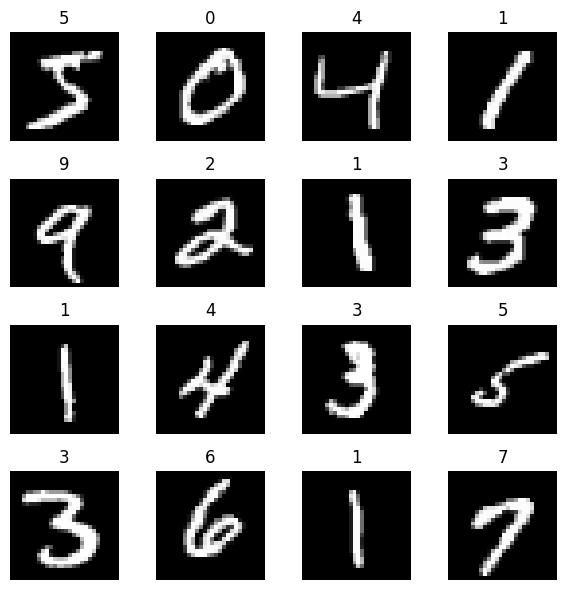

In [41]:
from matplotlib import pyplot as plt

def plot_grid(x, y, grid_size):
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            
            axes[i, j].imshow(x[idx], cmap='gray')
            axes[i, j].set_title(str(y[idx]))
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()
plot_grid(x_train, y_train, grid_size=4)


### Prepare the dataset

We will prepare the dataset by normalizing the pixel values and converting the labels to one-hot encoding.
> Images have pixel values ranging from 0 to 255. Normalizing these values to a range of 0 to 1 helps improve the convergence of the neural network during training.

In [42]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

We convert each image from a 28x28 array to a 784-dimensional vector (28 * 28 = 784) to feed into the feedforward neural network.
> numpy will calculate the size automatically with -1

In [43]:
X_train = x_train.reshape((x_train.shape[0], -1))
X_test = x_test.reshape((x_test.shape[0], -1))

Finally, we adjust our labels from 0-9 to one-hot encoded vectors.
> We can use sklearn's LabelBinarizer or Keras's to_categorical for this task.

In [44]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

print(f'New structure for labels: {y_train[0]}')

New structure for labels: [0 0 0 0 0 1 0 0 0 0]


This way the output layer of our neural network can have 10 neurons, each representing a class, and the target output for each image will be a vector with a 1 in the position corresponding to the correct class and 0s elsewhere.

### Design the neural network architecture

- Input Layer: 784 neurons (one for each pixel in the flattened image)
- Output Layer: 10 neurons (one for each class in the MNIST dataset)
- Activation Function: We have a multi-class classification problem, so we will use the softmax activation function in the output layer to get probabilities for each class.

In [45]:
from keras.models import Sequential
from keras.layers import Input, Dense

# We build the feedforward neural network
model = Sequential()
model.add(Input(shape=(784,)))  # Input layer
model.add(Dense(512, activation='relu'))  # Hidden layer with 512 neurons
model.add(Dense(256, activation='relu'))   # Hidden layer with 256 neurons
model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons for 10 classes

> We will use Stochastic Gradient Descent (SGD) as the optimizer, categorical crossentropy as the loss function (suitable for multi-class classification), and accuracy as the evaluation metric.

In [46]:
from keras.optimizers import SGD

opt = SGD(learning_rate=0.01)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
H = model.fit(X_train, y_train, epochs=20, batch_size=150, validation_data=(X_test, y_test)) 

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7468 - loss: 1.1494 - val_accuracy: 0.8706 - val_loss: 0.5562
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8803 - loss: 0.4718 - val_accuracy: 0.9001 - val_loss: 0.3856
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8983 - loss: 0.3731 - val_accuracy: 0.9099 - val_loss: 0.3308
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9073 - loss: 0.3305 - val_accuracy: 0.9177 - val_loss: 0.3009
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9141 - loss: 0.3036 - val_accuracy: 0.9228 - val_loss: 0.2807
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9191 - loss: 0.2839 - val_accuracy: 0.9244 - val_loss: 0.2665
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9240 - loss: 0.2681 - val_accuracy: 0.9286 - val_loss: 0.2520
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9277 - loss: 0.2549 - val_accuracy: 0.

After training the model, we will evaluate its performance on the test dataset and analyze the results.

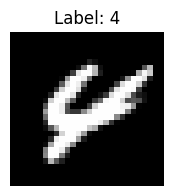

In [47]:
import numpy as np

# We plot a random image from the test set along with its label
index = np.random.randint(0, X_test.shape[0])
plt.figure(figsize=(2, 2))
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_test[index].argmax()}')
plt.axis('off')
plt.show()

And we validate the model by predicting a random image from the test set and displaying it along with its predicted label.

In [48]:
prediction = model.predict(X_test[index].reshape(1, -1))
predicted_class = np.argmax(prediction)
print(f'Actual: {np.argmax(y_test[index])}')
print(f'Predicted: {predicted_class}')
print(f'Prediction confidence: {prediction.max() * 100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Actual: 4
Predicted: 4
Prediction confidence: 52.12%


The results are really good with some digits being more difficult to classify due to their similar shapes.

In [49]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test, batch_size=150)
training_report = classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1))
print(training_report)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.95      0.95      1032
           3       0.93      0.96      0.95      1010
           4       0.95      0.95      0.95       982
           5       0.96      0.92      0.94       892
           6       0.95      0.96      0.96       958
           7       0.96      0.94      0.95      1028
           8       0.95      0.93      0.94       974
           9       0.95      0.94      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



Digits like '3' and '5' or '8' and '9' can be easily confused due to their similar structures, especially if the handwriting is not clear.

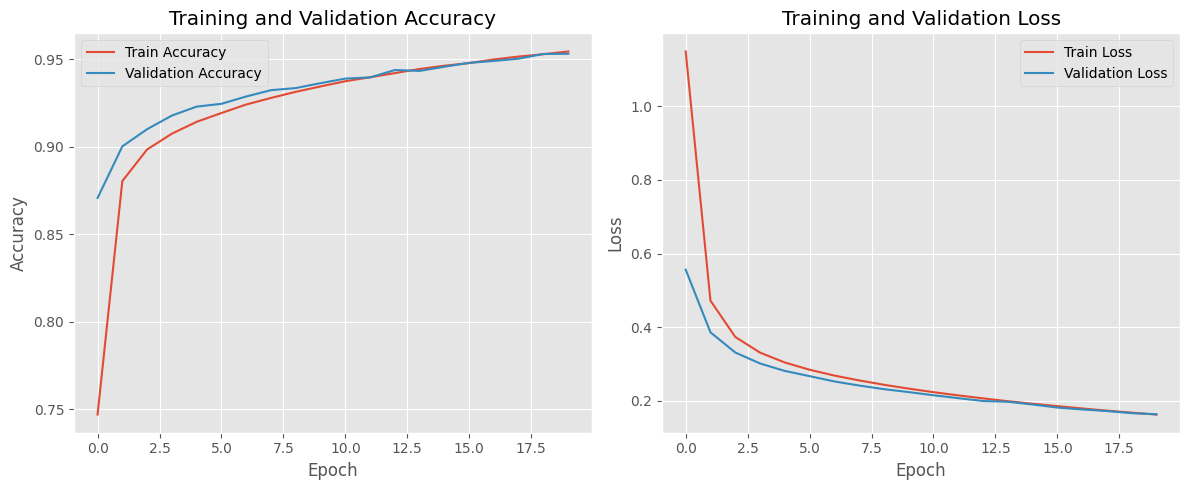

In [50]:
def print_training_metrics(H):
    """Plot training & validation accuracy and loss values"""
    plt.style.use("ggplot")
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(H.history['accuracy'], label='Train Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(H.history['loss'], label='Train Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print_training_metrics(H)

It doesn't need a lot of epochs to reach a good accuracy, as the model is relatively simple and the dataset is well-structured for this type of task. The results are good with an overall accuracy above 95%, but we could play with the number of layers and neurons to try to improve it even more. 